# Statistics Foundations

## 5. Significance


## What is a hypothesis?

In interpreting the results of a scientific study, we are usually wanting to be able to assess the "agreement" between theory and observation, to decide whether the theory stands up to the experimental evidence.



The idea of a hypothesis test is to be able to make a meaningful *rejection* of that theory, when there is enough evidence to suggest that it is incorrect.

## Null hypothesis

The *null hypothesis* in a hypothesis test represents a theoretical scenario that we can model in some way. It is usually given the symbol $H_{0}$.



$H_{0}$: The coin is fair, i.e. the probability of obtaining heads in any trial is 0.5

$H_{0}$: The mean amount of coffee dispensed by the machine is 200g.

$H_{0}$: The survival rates of the treatment group and the placebo group are the same.



We usually think about these models in the form of probability distributions, but sometimes it is easier to work with a simulation. The important thing is to be able to estimate what the results of the experiment would be, *if the null hypothesis were actually true*.

## A simple binomial simulation



```
import numpy as np
rng = np.random.default_rng(0)

# simulate 10 tosses of a fair coin - how many heads?
rng.binomial(n=10,p=0.5)
```

In [110]:
import numpy as np
rng = np.random.default_rng(0)

In [111]:

# simulate 10 tosses of a fair coin - how many heads?
rng.binomial(n=10,p=0.5)


6

## P-value

Imagine that I toss a coin 10 times and get only two heads. Is the coin fair?

Clearly it is not *impossible* for a fair coin to generate only two heads in ten trials. But it must be quite *unlikely*.

The *p-value* is a way to quantify how *unexpected* a particular outcome is, under the assumption that the null hypothesis is true. This gives us a mechanism for using our observed data to test the hypothesis.

## P-value by simulation



The null hypothesis is

$H_{0}$: The coin is fair, i.e. the probability of obtaining heads in any trial is 0.5



The experiment is

*Toss the coin 10 times and record the number of heads obtained.*



I can run my simulated experiment *assuming $H_{0}$* as many times as I like.

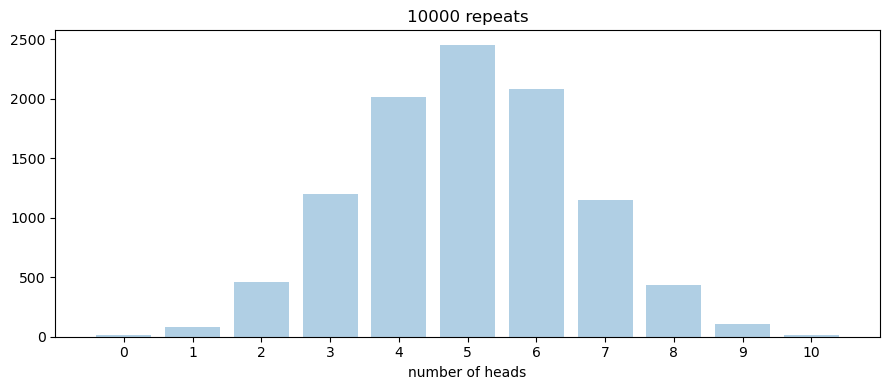

In [112]:
from ipywidgets import interact, FloatSlider, IntSlider
import matplotlib.pyplot as plt
import math

# reset rng
rng = np.random.default_rng(0)

# parameters coming from the experimental design
NUM_TRIALS = 10

# parameters coming from the null hypothesis
P_HEAD = 0.5

def plot_simulation(repeats):
    data = rng.binomial(n=NUM_TRIALS, p=P_HEAD, size=repeats)
    ks, fs = np.unique(data,return_counts=True)

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.bar(ks, fs, alpha=0.35, zorder=2)
    ax.set_xlim(-1, NUM_TRIALS + 1)
    ax.set_xticks(range(0, NUM_TRIALS + 1))
    ax.set_xlabel("number of heads")
    ax.set_title("{0} repeats".format(repeats))
    plt.tight_layout()
    plt.show()



plot_simulation(repeats=10000)

In [ ]:
interact(plot_simulation, repeats=IntSlider(min=1, max=10000, description="repeats"))
plt.show()

interactive(children=(IntSlider(value=1, description='repeats', max=10000, min=1), Output()), _dom_classes=('w…

The *p-value* is defined as the probability of obtaining a result *as extreme or more extreme* than the one observed. We have to decide what that means in each situation.



In our case, a result of 0, 1 or 2 heads would be "as extreme or more extreme" - i.e. the *lower tail* of the distribution.



I can therefore calculate the *empirical p-value* from my simulation.

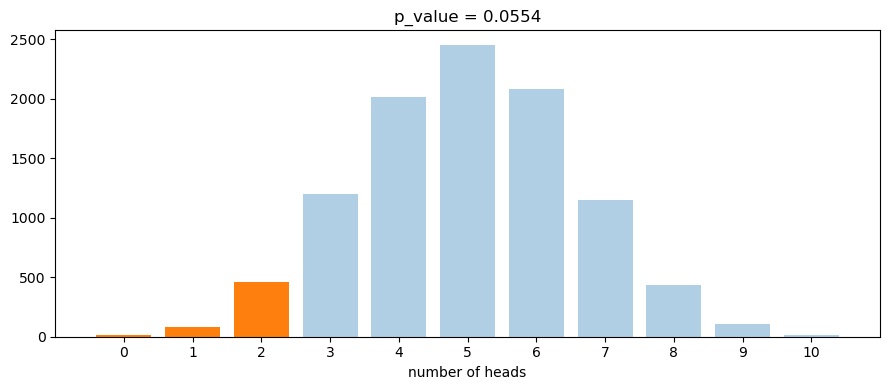

In [114]:
# reset rng
rng = np.random.default_rng(0)

def plot_empirical_p_value_lower_tail(repeats, observed):
    data = rng.binomial(n=NUM_TRIALS, p=P_HEAD, size=repeats)
    ks, fs = np.unique(data,return_counts=True)
    obs_index = 0
    for i in range(len(ks)):
        if ks[i] == observed:
            obs_index = i
    
    as_extreme_or_more_extreme = fs[:obs_index + 1].sum()
    p_value = as_extreme_or_more_extreme / repeats

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.bar(ks[obs_index + 1:], fs[obs_index + 1:], alpha=0.35, zorder=2)
    ax.bar(ks[:obs_index + 1], fs[:obs_index + 1], zorder=2)
    

    ax.set_xlim(-1, NUM_TRIALS + 1)
    ax.set_xticks(range(0, NUM_TRIALS + 1))
    ax.set_xlabel("number of heads")
    ax.set_title("p_value = {0}".format(p_value))
    plt.tight_layout()
    plt.show()

plot_empirical_p_value_lower_tail(repeats=10000, observed=2)

In [ ]:
interact(plot_empirical_p_value_lower_tail, observed=2, repeats=IntSlider(min=1, max=10000, description="repeats"))
plt.show()

interactive(children=(IntSlider(value=1, description='repeats', max=10000, min=1), IntSlider(value=2, descript…

## Significance level

The p-value gives me a readout of how surprising the observed result is, assuming that $H_{0}$ is true. 

* A tiny p-value means "very surprising".
* A p-value close to 0.5 means "not surprising at all".



To complete the hypothesis test, we need to make a decision about whether the p-value is *small enough* to lead us to doubt the validity of $H_{0}$. 



This decision is based on a threshold value known as $\alpha$, the significance level.



If p < $\alpha$, we say that we reject the null hypothesis as a reasonable explanation of the mechanism that generated the observed data.




The appropriate significance level depends a lot on the kind of science being done. 



* In a small wet-lab biology experiment, we may have a lot of uncontrollable sources of variability and very few repeats. In general, an $\alpha$ of 0.05 (5%) would be commonly accepted as appropriate.



* In a high-precision physics experiment, we may be able to eliminate a huge amount of variability, making much lower values of $\alpha$ appropriate.

Because many possible values of $\alpha$ could be justified, it is *essential* for the integrity of the hypothesis test to decide this value *before* making the observation and calculating the p-value. 



Before doing any calculations, you should get into the habit of writing down 

* the null hypothesis.
* whether the p-value corresponds to the lower or the upper tail.
* the chosen $\alpha$ value.

## Type I and Type II errors

Notice that there are two ways that the hypothesis test can give the incorrect result:

* $H_{0}$ is actually true, but I rejected it. (Type I error)
* $H_{0}$ is actually false, but I did not reject it. (Type II error)



We have direct control over the probability of a Type I error - this is simply the $\alpha$ value itself.

e.g. if I set $\alpha = 0.05$ then I accept that if the null hypothesis is true, I will reject it 5% of the time.

1 - $\alpha$ is known as the *specificity* of the study.



The probability of making a Type II error (known as $\beta$) is in general difficult to estimate accurately, as it may depend on unknown population parameters. 


1 - $\beta$ is known as the *power* of the study.


## P-values from probability distributions

If the theoretical situation described by the null hypothesis corresponds to a known probability distribution over the outcomes of the experiment, then we can calculate the p-value exactly instead of using a simulation.

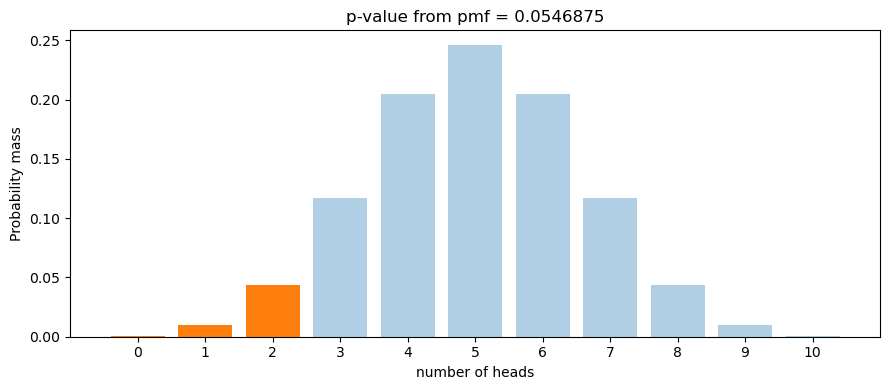

In [116]:

def binom_pmf(k, p, n=100):
    """Binomial pmf for X ~ Bin(n, p)"""
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

def plot_binomial_lower_tail(observed):
    ks = np.arange(0, NUM_TRIALS+1)
    probs = np.array([binom_pmf(k, P_HEAD, NUM_TRIALS) for k in ks])

    as_extreme_or_more_extreme = probs[:observed + 1].sum()
    p_value = as_extreme_or_more_extreme / 1.0  # pmf sums to 1

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.bar(ks[observed + 1:], probs[observed + 1:], alpha=0.35, zorder=2)
    ax.bar(ks[:observed + 1], probs[:observed + 1], zorder=2)


    ax.set_xlim(-1, NUM_TRIALS+1)
    ax.set_xlabel("number of heads")
    ax.set_xticks(range(0, NUM_TRIALS + 1))
    ax.set_ylabel("Probability mass")
    ax.set_title("p-value from pmf = {}".format(p_value))
    plt.tight_layout()
    plt.show()

plot_binomial_lower_tail(observed=2)

## Summary: basic procedure for a hypothesis test

1. Formulate the null hypothesis $H_{0}$
2. Decide the significance level $\alpha$
3. Make the measurement / observation
4. Calculate the p-value (by simulation or using a known probability distribution)
5. If p < $\alpha$, reject $H_{0}$

Next time we will introduce the idea of *test statistics* and look at some parametric hypothesis tests in more detail.